<a href="https://colab.research.google.com/github/IsaiasSCordeiro/mvp-churn-sva/blob/main/4052026000288_IsaiasCordeiro_MVP_ML_Analytics_20261_VF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Isaías Silva Cordeiro_  
**Matrícula:** _4052026000288_  
**Data:** _05/07/2026_  
**Dataset:**  _Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data_  
**Tipo de problema:** _Classificação_  

---



# 1. Definição do problema

## 1.1 Descrição do problema

- **Qual é o contexto do problema?**

    Muitos clientes optam por descontinuar a utilização de serviços que não proporcionam percepção de ganho de valor contínuo. Nesse contexto, os Serviços de Valor Agregado (SVA) desempenham papel relevante na retenção desses clientes.

    Modelos de negócio baseados em assinatura enfrentam desafios significativos no mercado, uma vez que estão sujeitos à perda recorrente de base. Essa dinâmica transforma o processo de aquisição de clientes em um ciclo contínuo de esforço, no qual, mesmo diante de elevados índices de captação, há comprometimento da receita recorrente, visto que o Custo de Aquisição de Cliente (CAC) tende a ser elevado, impactando diretamente a rentabilidade do negócio.

    Diante disso, a análise do impacto da utilização dos SVA sobre o Churn, métrica que representa o cancelamento ou evasão de clientes, torna-se indispensável para a saúde financeira de negócios estruturados no modelo de receita recorrente mensal (Monthly Recurring Revenue — MRR).

- **Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?**

    A classificação de apio deve ser a que identifique quais modalidades de Serviços de Valor Agregado (SVA) exercem maior impacto na retenção de clientes, isto é, aquelas associadas à menor incidência de Churn.


- **Quem seria o usuário ou interessado nessa solução?**

    O público primário desta análise é composto por diretores e CEOs, responsáveis pelas decisões estratégicas que asseguram que o produto principal não sofra efeito contrário à proposta dos SVA, ou seja, que a insatisfação com um serviço auxiliar não se torne fator determinante para o cancelamento do serviço core.

- **Por que esse problema é relevante?**

    Este problema é relevante por dois fatores de impacto financeiro direto. O primeiro corresponde à perda de receita oriunda do cancelamento do serviço principal (core) motivado pela insatisfação do cliente com o serviço SVA, resultado oposto ao objetivo para o qual o serviço auxiliar foi concebido. O segundo refere-se à perda de receita decorrente da manutenção de serviços que não agregam valor estratégico ao negócio.


## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  

  Desenvolver um modelo preditivo capaz de identificar quais Serviços de Valor Agregado (SVA) exercem maior impacto na retenção de clientes, subsidiando decisões estratégicas voltadas à redução do Churn
 e à eliminação de serviços sem viabilidade financeira para o negócio.


## 1.3 Tipo de problema

**Tipo escolhido:**

Classificação


**Justificativa:**  
O problema consiste em prever se um cliente irá ou não cancelar o serviço (Churn = Sim / Não), resultado que assume apenas duas categorias discretas e mutuamente exclusivas. Por essa razão, trata-se de um problema de classificação binária, em que o modelo aprende a partir de exemplos rotulados historicamente para identificar padrões de comportamento associados ao cancelamento. O escopo do modelo é restrito às variáveis de Serviços de Valor Agregado (SVAs), decisão intencional que visa isolar a contribuição específica desses serviços na retenção de clientes, sem interferência de variáveis contratuais ou financeiras.

## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. Clientes sem nenhum SVA contratado apresentam taxa de churn superior à média geral da base, sugerindo que a ausência de SVAs está associada a maior risco de cancelamento.
2. O padrão de contratação de SVAs reflete o nível de engajamento do cliente com o serviço, sendo possível que clientes com maior número de SVAs ativos apresentem menor propensão ao churn do que clientes com poucos SVAs contratados.
3. Nem todos os SVAs exercem o mesmo peso na decisão de permanência do cliente, sendo possível identificar serviços com baixa ou nula contribuição para a retenção, candidatos à eliminação por ausência de viabilidade financeira.

**Critérios de sucesso:**
- **Métrica principal:** F1-score
- **Resultado mínimo esperado:** O modelo candidato deve superar o baseline em pelo menos 5 pontos percentuais de F1-score ponderado, atingindo resultado igual ou superior a 0,65.
- **Restrição prática:** O modelo deve ser interpretável o suficiente para comunicar resultados a tomadores de decisão não técnicos. Por essa razão, priorizou-se o Random Forest com análise de importância de features em detrimento de modelos de maior complexidade e menor explicabilidade. Adicionalmente, o projeto deve ser executável integralmente no Google Colab sem dependências externas além das bibliotecas padrão, garantindo reprodutibilidade via SEED = 42.

# 2. Ambiente, bibliotecas e reprodutibilidade

In [ ]:
import os, sys, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

# Seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Ambiente
print("Python :", sys.version.split()[0])
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("sklearn:", sklearn.__version__)
print("Seed   :", SEED)



Python : 3.12.13
numpy  : 2.0.2
pandas : 2.2.2
sklearn: 1.6.1
Seed   : 42


## 2.2 Funções auxiliares


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    results = {
        "accuracy"    : accuracy_score(y_true, y_pred),
        "f1_weighted" : f1_score(y_true, y_pred, average="weighted")
    }
    try:
        if proba is not None:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan
    return results

def show_results_table(results_dict):
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset *Telco Customer Churn*, disponibilizado publicamente pela IBM e acessível em https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data, contém dados de uma empresa fictícia de telecomunicações composta por 7.043 registros de clientes com serviços de telefonia e internet por assinatura, descrevendo o perfil de cada cliente em um corte temporal único. Para cada registro, estão disponíveis informações demográficas, contratuais, financeiras e de utilização de serviços — incluindo os Serviços de Valor Agregado (SVAs). A variável-alvo indica se o cliente cancelou o serviço (Churn = Yes) ou permaneceu ativo (Churn = No) até o momento do corte.

Este dataset foi selecionado por duas razões complementares. A primeira é sua aderência ao contexto profissional do autor: a base contém informações sobre SVAs em um modelo de negócio por assinatura, tema diretamente relacionado à atuação do pesquisador e ao objetivo de aplicação prática dos conhecimentos adquiridos na pós-graduação. A segunda razão é a escassez de dados públicos equivalentes: datasets reais contendo informações detalhadas sobre SVAs raramente são disponibilizados publicamente, dado o impacto estratégico que esse tipo de informação representa para empresas do setor de telecomunicações. O *Telco Customer Churn* constitui, portanto, a base pública disponível que mais se aproxima do cenário real de aplicação pretendido, tornando-o adequado tanto para o desenvolvimento do modelo preditivo quanto para o aprendizado prático de técnicas de Machine Learning aplicadas à retenção de clientes.

Como restrições, destacam-se: o caráter sintético dos dados, que impede extrapolação direta para operações reais; o corte temporal único, que inviabiliza análises sequenciais de comportamento; e o desbalanceamento do target, com aproximadamente 26% de registros de churn, considerado na escolha da métrica de avaliação e na estratégia de divisão treino/teste. Quanto às questões éticas, de privacidade e licenciamento, o dataset é de uso público, licenciado sob os termos da plataforma Kaggle para fins educacionais e de pesquisa. Por se tratar de dados sintéticos gerados artificialmente pela IBM sem vínculo com clientes reais, não há exposição de informações pessoais identificáveis, inexistindo conflito com a Lei Geral de Proteção de Dados (LGPD) ou restrições de confidencialidade. O uso do dataset neste projeto é estritamente acadêmico, sem finalidade comercial.

## 3.2 Carga dos dados

In [ ]:

url = "https://raw.githubusercontent.com/IsaiasSCordeiro/mvp-churn-sva/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

bd = df.copy()

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Linhas: 7043 | Colunas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.3 Visão geral do dataset


In [ ]:
print("=== Dimensões do dataset ===")
print(f"Linhas  : {df.shape[0]}")
print(f"Colunas : {df.shape[1]}")

=== Dimensões do dataset ===
Linhas  : 7043
Colunas : 21


In [ ]:
# Tipos dos atributos
print("\n=== Tipos dos atributos ===")
print(df.dtypes)


=== Tipos dos atributos ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
print("\n=== Valores ausentes por coluna ===")
display(df.isnull().sum().to_frame("ausentes"))


=== Valores ausentes por coluna ===


,ausentes
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print("\n=== Duplicatas ===")
print(f"Linhas duplicadas: {df.duplicated().sum()}")


=== Duplicatas ===
Linhas duplicadas: 0


In [ ]:
# Colunas excluídas do modelo e justificativa

print("=== Colunas excluídas do modelo ===\n")

exclusoes = {
    "customerID"       : "Identificador único do cliente — sem valor preditivo.",
    "gender"           : "Variável demográfica — fora do escopo SVA.",
    "SeniorCitizen"    : "Variável demográfica — fora do escopo SVA.",
    "Partner"          : "Variável demográfica — fora do escopo SVA.",
    "Dependents"       : "Variável demográfica — fora do escopo SVA.",
    "tenure"           : "Tempo de contrato — variável contratual, fora do escopo SVA.",
    "PhoneService"     : "Serviço base de telefonia — não é SVA.",
    "MultipleLines"    : "Serviço base de telefonia — não é SVA.",
    "InternetService"  : "Serviço base de internet — não é SVA.",
    "Contract"         : "Tipo de contrato — variável contratual, fora do escopo SVA.",
    "PaperlessBilling" : "Forma de cobrança — variável contratual, fora do escopo SVA.",
    "PaymentMethod"    : "Método de pagamento — variável financeira, fora do escopo SVA.",
    "MonthlyCharges"   : "Valor mensal — variável financeira, fora do escopo SVA.",
    "TotalCharges"     : "Valor total acumulado — variável financeira, fora do escopo SVA."
}

for coluna, motivo in exclusoes.items():
    print(f"  {coluna:20s} → {motivo}")


=== Colunas excluídas do modelo ===

  customerID           → Identificador único do cliente — sem valor preditivo.
  gender               → Variável demográfica — fora do escopo SVA.
  SeniorCitizen        → Variável demográfica — fora do escopo SVA.
  Partner              → Variável demográfica — fora do escopo SVA.
  Dependents           → Variável demográfica — fora do escopo SVA.
  tenure               → Tempo de contrato — variável contratual, fora do escopo SVA.
  PhoneService         → Serviço base de telefonia — não é SVA.
  MultipleLines        → Serviço base de telefonia — não é SVA.
  InternetService      → Serviço base de internet — não é SVA.
  Contract             → Tipo de contrato — variável contratual, fora do escopo SVA.
  PaperlessBilling     → Forma de cobrança — variável contratual, fora do escopo SVA.
  PaymentMethod        → Método de pagamento — variável financeira, fora do escopo SVA.
  MonthlyCharges       → Valor mensal — variável financeira, fora do escopo 

In [ ]:
# Descrição do target (Churn)

print("=== Descrição do target ===\n")

contagem   = df['Churn'].value_counts()
percentual = df['Churn'].value_counts(normalize=True).mul(100).round(2)

print(f"Nome da coluna : Churn")
print(f"Tipo           : {df['Churn'].dtype}")
print(f"Valores únicos : {df['Churn'].unique()}")
print(f"\nDistribuição:")
print(f"  Churn = No  : {contagem['No']:>4} registros ({percentual['No']}%)")
print(f"  Churn = Yes : {contagem['Yes']:>4} registros ({percentual['Yes']}%)")
print(f"\nEncoding aplicado na modelagem:")
print(f"  Churn = No  → 0 (cliente ativo)")
print(f"  Churn = Yes → 1 (cliente cancelou)")

=== Descrição do target ===

Nome da coluna : Churn
Tipo           : object
Valores únicos : ['No' 'Yes']

Distribuição:
  Churn = No  : 5174 registros (73.46%)
  Churn = Yes : 1869 registros (26.54%)

Encoding aplicado na modelagem:
  Churn = No  → 0 (cliente ativo)
  Churn = Yes → 1 (cliente cancelou)


In [ ]:
print("=== Amostra do dataset ===\n")
display(df.sample(5, random_state=SEED))

=== Amostra do dataset ===



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## 3.4 Dicionário de dados



In [ ]:
import pandas as pd

dicionario = pd.DataFrame([
    {"Coluna": "customerID",       "Tipo": "texto",       "Descrição": "Identificador único do cliente",                          "Usado no modelo": "Não",  "Observações": "Sem valor preditivo — excluído do modelo"},
    {"Coluna": "gender",           "Tipo": "categórica",  "Descrição": "Gênero do cliente (Male/Female)",                         "Usado no modelo": "Não",  "Observações": "Variável demográfica — fora do escopo SVA"},
    {"Coluna": "SeniorCitizen",    "Tipo": "numérica",    "Descrição": "Indica se o cliente é idoso (0/1)",                       "Usado no modelo": "Não",  "Observações": "Variável demográfica — fora do escopo SVA"},
    {"Coluna": "Partner",          "Tipo": "categórica",  "Descrição": "Indica se o cliente tem cônjuge (Yes/No)",                "Usado no modelo": "Não",  "Observações": "Variável demográfica — fora do escopo SVA"},
    {"Coluna": "Dependents",       "Tipo": "categórica",  "Descrição": "Indica se o cliente tem dependentes (Yes/No)",            "Usado no modelo": "Não",  "Observações": "Variável demográfica — fora do escopo SVA"},
    {"Coluna": "tenure",           "Tipo": "numérica",    "Descrição": "Tempo de contrato em meses",                              "Usado no modelo": "Não",  "Observações": "Variável contratual — fora do escopo SVA"},
    {"Coluna": "PhoneService",     "Tipo": "categórica",  "Descrição": "Indica se possui serviço de telefonia (Yes/No)",          "Usado no modelo": "Não",  "Observações": "Serviço base — não é SVA"},
    {"Coluna": "MultipleLines",    "Tipo": "categórica",  "Descrição": "Indica se possui múltiplas linhas (Yes/No)",              "Usado no modelo": "Não",  "Observações": "Serviço base — não é SVA"},
    {"Coluna": "InternetService",  "Tipo": "categórica",  "Descrição": "Tipo de serviço de internet contratado",                  "Usado no modelo": "Não",  "Observações": "Serviço base — não é SVA"},
    {"Coluna": "OnlineSecurity",   "Tipo": "categórica",  "Descrição": "Serviço de segurança online (Yes/No)",                   "Usado no modelo": "Sim",  "Observações": "SVA — feature do modelo"},
    {"Coluna": "OnlineBackup",     "Tipo": "categórica",  "Descrição": "Serviço de backup online (Yes/No)",                      "Usado no modelo": "Sim",  "Observações": "SVA — feature do modelo"},
    {"Coluna": "DeviceProtection", "Tipo": "categórica",  "Descrição": "Serviço de proteção de dispositivo (Yes/No)",            "Usado no modelo": "Sim",  "Observações": "SVA — feature do modelo"},
    {"Coluna": "TechSupport",      "Tipo": "categórica",  "Descrição": "Serviço de suporte técnico (Yes/No)",                    "Usado no modelo": "Sim",  "Observações": "SVA — feature do modelo"},
    {"Coluna": "StreamingTV",      "Tipo": "categórica",  "Descrição": "Serviço de streaming de TV (Yes/No)",                    "Usado no modelo": "Sim",  "Observações": "SVA — feature do modelo"},
    {"Coluna": "StreamingMovies",  "Tipo": "categórica",  "Descrição": "Serviço de streaming de filmes (Yes/No)",                "Usado no modelo": "Sim",  "Observações": "SVA — feature do modelo"},
    {"Coluna": "Contract",         "Tipo": "categórica",  "Descrição": "Tipo de contrato (Month-to-month/One year/Two year)",    "Usado no modelo": "Não",  "Observações": "Variável contratual — fora do escopo SVA"},
    {"Coluna": "PaperlessBilling", "Tipo": "categórica",  "Descrição": "Indica se utiliza fatura digital (Yes/No)",              "Usado no modelo": "Não",  "Observações": "Variável contratual — fora do escopo SVA"},
    {"Coluna": "PaymentMethod",    "Tipo": "categórica",  "Descrição": "Método de pagamento utilizado",                          "Usado no modelo": "Não",  "Observações": "Variável financeira — fora do escopo SVA"},
    {"Coluna": "MonthlyCharges",   "Tipo": "numérica",    "Descrição": "Valor da mensalidade em dólares",                        "Usado no modelo": "Não",  "Observações": "Variável financeira — fora do escopo SVA"},
    {"Coluna": "TotalCharges",     "Tipo": "numérica",    "Descrição": "Valor total acumulado em dólares",                       "Usado no modelo": "Não",  "Observações": "Variável financeira — fora do escopo SVA"},
    {"Coluna": "Churn",            "Tipo": "alvo",        "Descrição": "Indica se o cliente cancelou o serviço (Yes/No)",        "Usado no modelo": "Alvo", "Observações": "Convertida para 0 (ativo) e 1 (cancelou) na modelagem"},
])

display(dicionario)

,Coluna,Tipo,Descrição,Usado no modelo,Observações
0,customerID,texto,Identificador único do cliente,Não,Sem valor preditivo — excluído do modelo
1,gender,categórica,Gênero do cliente (Male/Female),Não,Variável demográfica — fora do escopo SVA
2,SeniorCitizen,numérica,Indica se o cliente é idoso (0/1),Não,Variável demográfica — fora do escopo SVA
3,Partner,categórica,Indica se o cliente tem cônjuge (Yes/No),Não,Variável demográfica — fora do escopo SVA
4,Dependents,categórica,Indica se o cliente tem dependentes (Yes/No),Não,Variável demográfica — fora do escopo SVA
5,tenure,numérica,Tempo de contrato em meses,Não,Variável contratual — fora do escopo SVA
6,PhoneService,categórica,Indica se possui serviço de telefonia (Yes/No),Não,Serviço base — não é SVA
7,MultipleLines,categórica,Indica se possui múltiplas linhas (Yes/No),Não,Serviço base — não é SVA
8,InternetService,categórica,Tipo de serviço de internet contratado,Não,Serviço base — não é SVA
9,OnlineSecurity,categórica,Serviço de segurança online (Yes/No),Sim,SVA — feature do modelo


# 4. Análise exploratória dos dados


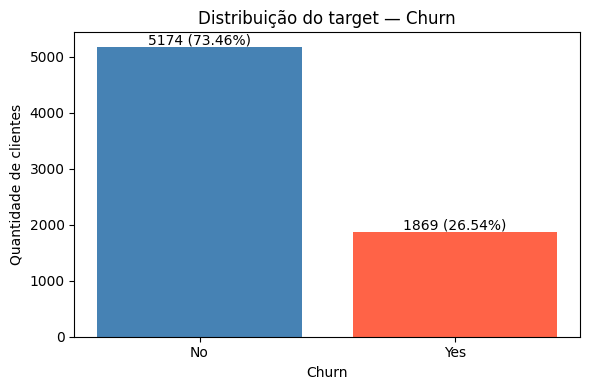

In [ ]:
# Distribuição do target (Churn)

contagem   = df['Churn'].value_counts()
percentual = df['Churn'].value_counts(normalize=True).mul(100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(contagem.index, contagem.values, color=['steelblue', 'tomato'])
ax.set_title('Distribuição do target — Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Quantidade de clientes')
for i, (v, p) in enumerate(zip(contagem.values, percentual.values)):
    ax.text(i, v + 50, f'{v} ({p}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

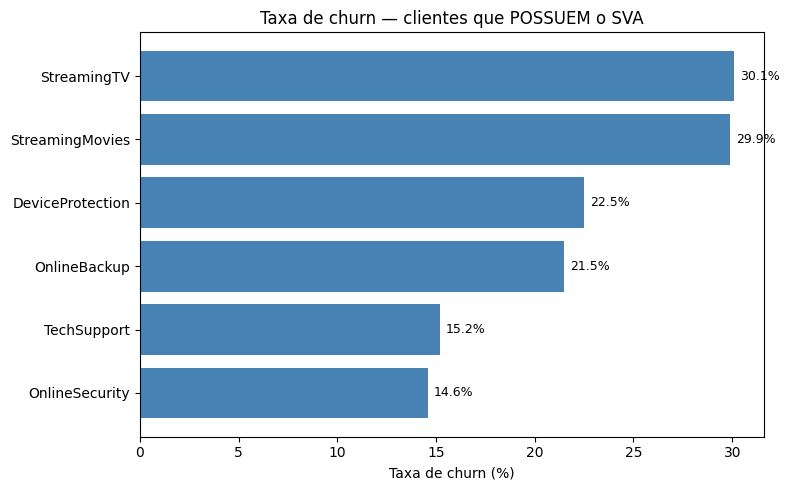

In [ ]:
# Taxa de churn por SVA — clientes que TÊM o serviço

SVAS = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

taxas_com = {}
for sva in SVAS:
    grupo = df[df[sva] == 'Yes']
    taxa  = (grupo['Churn'] == 'Yes').sum() / len(grupo) * 100
    taxas_com[sva] = round(taxa, 1)

taxas_com_s = pd.Series(taxas_com).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(taxas_com_s.index, taxas_com_s.values, color='steelblue')
ax.set_title('Taxa de churn — clientes que POSSUEM o SVA')
ax.set_xlabel('Taxa de churn (%)')
for bar, val in zip(bars, taxas_com_s.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

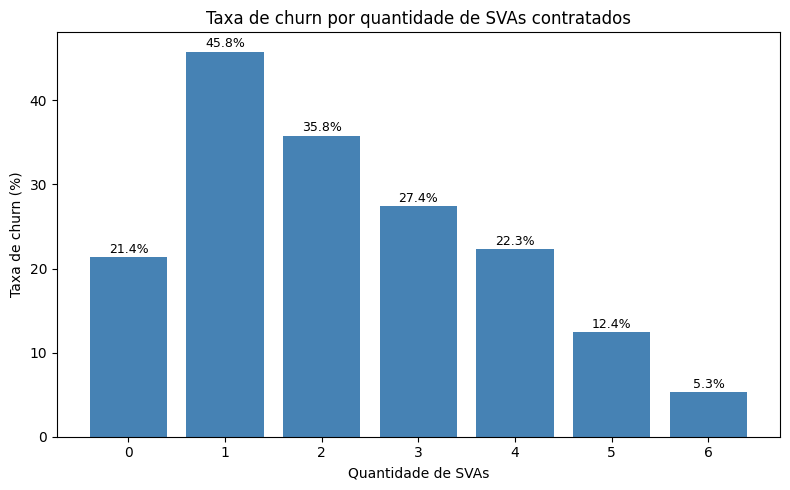

In [ ]:
# Churn por quantidade de SVAs contratados


bd['Qtd_Servicos_SVA'] = (bd[SVAS] == 'Yes').sum(axis=1)

taxa_por_qtd = bd.groupby('Qtd_Servicos_SVA')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(taxa_por_qtd.index, taxa_por_qtd.values, color='steelblue')
ax.set_title('Taxa de churn por quantidade de SVAs contratados')
ax.set_xlabel('Quantidade de SVAs')
ax.set_ylabel('Taxa de churn (%)')
for bar, val in zip(bars, taxa_por_qtd.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

A análise exploratória revelou que a base apresenta desbalanceamento entre as classes: 73,46% dos registros correspondem a clientes ativos (5.174 clientes) e 26,54% a clientes que cancelaram (1.869 clientes), o que determinou a adoção do F1-score ponderado como métrica principal e o uso de stratify=y na divisão treino/teste. Valores ausentes foram identificados apenas na coluna TotalCharges, sem impacto na modelagem dado que essa coluna está fora do escopo SVA. As 6 variáveis SVA utilizadas são todas categóricas (Yes/No), sem diferença de escala entre elas, dispensando normalização — tratamento realizado exclusivamente via OneHotEncoder no Pipeline. A categoria No internet service foi padronizada como No no pré-processamento por representar ausência do serviço.

A análise de churn por quantidade de SVAs contratados revelou tendência de queda consistente: clientes com 1 SVA apresentam taxa de churn de 45,8%, enquanto clientes com 6 SVAs registram apenas 5,3% — confirmando a Hipótese 2 ainda na fase exploratória e favorecendo modelos baseados em árvore, como Decision Tree e Random Forest, que capturam interações entre variáveis sem assumir linearidade. A análise por SVA individual indica que OnlineSecurity (14,6%) e TechSupport (15,2%) estão associados às menores taxas de churn entre contratantes, enquanto StreamingTV (30,1%) e StreamingMovies (29,9%) apresentam taxas próximas à média geral da base, sugerindo menor impacto isolado na retenção._


# 5. Preparação dos dados e divisão treino/teste


In [ ]:
# Preparação dos dados e divisão treino/teste

SVAS = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

df_model = df[SVAS + ['Churn']].copy()

df_model[SVAS] = df_model[SVAS].replace(
    {'No internet service': 'No', 'No phone service': 'No'})

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

print("=== Features selecionadas ===")
print(SVAS)
print(f"\n=== Target ===")
print("Churn — 0 (ativo) | 1 (cancelou)")
print(f"\n=== Dimensões após seleção ===")
print(f"Linhas: {df_model.shape[0]} | Colunas: {df_model.shape[1]}")

=== Features selecionadas ===
['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

=== Target ===
Churn — 0 (ativo) | 1 (cancelou)

=== Dimensões após seleção ===
Linhas: 7043 | Colunas: 7


In [ ]:
# Separação features e target

X = df_model[SVAS]
y = df_model['Churn']

In [ ]:
# Primeiros 10 registros reservados para verificação manual

features_conferencia = X.iloc[:10]
labels_conferencia   = y.iloc[:10]

print("\n=== Registros reservados para conferência manual ===")
print(f"features_conferencia : {features_conferencia.shape}")
print(f"labels_conferencia   : {labels_conferencia.shape}")


=== Registros reservados para conferência manual ===
features_conferencia : (10, 6)
labels_conferencia   : (10,)


In [ ]:
# Base de modelagem — remove os 10 primeiros
X = X.iloc[10:]
y = y.iloc[10:]

In [ ]:
# Divisão treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print("\n=== Divisão treino/teste ===")
print(f"Treino : {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Teste  : {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\n=== Proporção de churn por conjunto ===")
print(f"Treino — Churn: {y_train.mean()*100:.1f}%")
print(f"Teste  — Churn: {y_test.mean()*100:.1f}%")



=== Divisão treino/teste ===
Treino : 5626 registros (80.0%)
Teste  : 1407 registros (20.0%)

=== Proporção de churn por conjunto ===
Treino — Churn: 26.5%
Teste  — Churn: 26.5%


## 5.1 Justificativa da divisão
  
 A divisão escolhida foi o **holdout** — separação única entre treino e teste — na proporção 80/20, com estratificação por classe.

O holdout é adequado para este projeto porque o dataset possui 7.043 registros, volume suficiente para que ambos os conjuntos sejam representativos sem necessidade de validação cruzada. A validação cruzada seria mais indicada em bases menores, onde uma única divisão poderia gerar conjuntos não representativos por variação amostral.

A proporção 80/20 é o padrão consolidado para datasets de tamanho médio: reservar 80% para treino garante que o modelo aprenda com volume adequado de exemplos, enquanto os 20% de teste — aproximadamente 1.400 registros — são suficientes para uma avaliação estatisticamente confiável do desempenho.

A estratificação por classe (stratify=y) foi necessária dado o desbalanceamento identificado na EDA: 73,46% de clientes ativos e 26,54% em churn. Sem estratificação, a divisão aleatória poderia gerar um conjunto de teste com proporção de churn diferente da base original — comprometendo a confiabilidade da avaliação. Com stratify=y, a proporção de 26,54% de churn é mantida igualmente em treino e teste.

O vazamento de dados foi evitado pela separação dos 10 registros de conferência manual (features_conferencia e labels_conferencia) antes da divisão treino/teste, e pelo uso do Pipeline com ColumnTransformer — que aplica o OneHotEncoder exclusivamente nos dados de treino e replica a transformação no teste, sem que informações do conjunto de teste influenciem o pré-processamento.


# 6. Pré-processamento e pipeline



In [ ]:
# Identificação automática de colunas numéricas e categóricas.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Colunas numéricas  :", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas  : []
Colunas categóricas: ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [ ]:
# Pipeline numérico — mantido na estrutura padrão

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler" , StandardScaler())
])

In [ ]:
# Pipeline categórico

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot" , OneHotEncoder(handle_unknown="ignore"))
])


preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("\n=== Estrutura do Pipeline ===")
print("ColumnTransformer")
print("  ├── num → SimpleImputer (median) → StandardScaler   [vazio neste MVP]")
print("  └── cat → SimpleImputer (most_frequent) → OneHotEncoder")


=== Estrutura do Pipeline ===
ColumnTransformer
  ├── num → SimpleImputer (median) → StandardScaler   [vazio neste MVP]
  └── cat → SimpleImputer (most_frequent) → OneHotEncoder


## 6.1 Decisões de pré-processamento

Por que usei moda para imputação?

As features do modelo são todas categóricas (Yes/No). Para variáveis categóricas, a moda — valor mais frequente — é a única estratégia de imputação estatisticamente adequada. Média e mediana se aplicam exclusivamente a variáveis numéricas contínuas. Na prática, os SVAs do dataset Telco Churn não apresentam valores ausentes, portanto o SimpleImputer atua como salvaguarda para garantir que o Pipeline não quebre em dados novos com eventuais nulos.

Por que não normalizei ou padronizei os dados?

Normalização (MinMaxScaler) e padronização (StandardScaler) são transformações aplicadas a variáveis numéricas para colocá-las na mesma escala. Como todas as features SVA são categóricas, essas transformações não se aplicam. O OneHotEncoder já converte as categorias em colunas binárias 0/1 — que estão naturalmente na mesma escala entre si.

Quais variáveis foram removidas e por quê?

Das 21 colunas do dataset, 15 foram excluídas do modelo. A coluna customerID foi removida por ser um identificador único sem valor preditivo. As demais 14 colunas — demográficas, contratuais e financeiras — foram excluídas por estarem fora do escopo SVA. Essa exclusão é uma decisão metodológica deliberada: incluí-las tornaria impossível isolar o impacto específico dos SVAs na retenção, que é o objetivo central do MVP.

Criei novas variáveis?

Sim. A coluna Qtd_Servicos_SVA foi criada na fase exploratória para verificar a Hipótese 2 — se clientes com maior número de SVAs ativos apresentam menor propensão ao churn. Essa variável não foi incluída como feature do modelo preditivo, pois é derivada das próprias colunas SVA já presentes — sua inclusão geraria redundância sem adicionar informação nova ao modelo. Em um cenário real de produção, ela estaria disponível no momento da previsão, pois pode ser calculada diretamente a partir dos registros de contratação do cliente.


# 7. Baseline e modelos candidatos

In [ ]:
# Baseline — DummyClassifier

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

results = {}
results["Baseline"] = evaluate_classification(y_test, y_pred_base)
results["Baseline"]["train_time_s"] = 0.0

print("=== Baseline — DummyClassifier (most_frequent) ===\n")
print(classification_report(y_test, y_pred_base,
                             target_names=["Ativo", "Churn"]))



=== Baseline — DummyClassifier (most_frequent) ===

              precision    recall  f1-score   support

       Ativo       0.73      1.00      0.85      1034
       Churn       0.00      0.00      0.00       373

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



In [ ]:
# Modelos candidatos

candidates = {
    "Naive Bayes"   : Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GaussianNB())
    ]),
    "Decision Tree" : Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=SEED))
    ]),
    "Random Forest" : Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))
    ])
}

trained_models = {}

for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba  = model.predict_proba(X_test) if hasattr(
        model.named_steps["model"], "predict_proba") else None

    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

    print(f"\n=== {name} ===\n")
    print(classification_report(y_test, y_pred,
                                 target_names=["Ativo", "Churn"]))



=== Naive Bayes ===

              precision    recall  f1-score   support

       Ativo       0.78      0.51      0.62      1034
       Churn       0.31      0.60      0.41       373

    accuracy                           0.53      1407
   macro avg       0.54      0.55      0.51      1407
weighted avg       0.65      0.53      0.56      1407


=== Decision Tree ===

              precision    recall  f1-score   support

       Ativo       0.77      0.94      0.84      1034
       Churn       0.55      0.20      0.30       373

    accuracy                           0.75      1407
   macro avg       0.66      0.57      0.57      1407
weighted avg       0.71      0.75      0.70      1407


=== Random Forest ===

              precision    recall  f1-score   support

       Ativo       0.77      0.94      0.84      1034
       Churn       0.55      0.20      0.30       373

    accuracy                           0.75      1407
   macro avg       0.66      0.57      0.57      1407
weig

In [ ]:
#Tabela comparativa inicial

print("\n=== Comparativo inicial dos modelos ===\n")
display(show_results_table(results))


=== Comparativo inicial dos modelos ===



,accuracy,f1_weighted,roc_auc,train_time_s
Baseline,0.734897,0.622600,NaN,0.000
Naive Bayes,0.533049,0.559857,0.611160,0.028
Decision Tree,0.745558,0.699718,0.659154,0.027
Random Forest,0.745558,0.699718,0.659501,0.295


## 7.1 Justificativa dos modelos

O baseline escolhido é o DummyClassifier com estratégia de classe majoritária, que classifica todos os clientes como ativos sem analisar nenhuma feature. Essa escolha é coerente com o problema porque estabelece o piso mínimo de desempenho: qualquer modelo que não supere 74% de acurácia — proporção da classe majoritária — não justifica sua aplicação em relação a uma regra simples.

Os três modelos candidatos são adequados ao tipo e tamanho dos dados por razões distintas. O Naive Bayes é indicado para features categóricas binárias e base de tamanho médio, operando com rapidez e sem exigências computacionais relevantes — sua limitação é a suposição de independência entre os SVAs, que raramente se verifica na prática. A Decision Tree captura interações entre SVAs sem assumir linearidade e produz regras interpretáveis — os primeiros nós da árvore revelam quais SVAs o modelo considera mais decisivos, o que tem valor estratégico direto para o objetivo do MVP. O Random Forest supera a instabilidade da árvore individual ao combinar 100 árvores com amostras diferentes, gerando um ranking de importância de features mais robusto e confiável para subsidiar decisões de portfólio.

Nenhum modelo candidato exige normalização ou padronização, pois todas as features SVA são categóricas. O OneHotEncoder aplicado no Pipeline é suficiente para o encoding necessário. O Naive Bayes recebe as features já transformadas pelo Pipeline, o que é adequado para o GaussianNB utilizado.

A principal restrição do projeto é interpretabilidade: os resultados precisam ser comunicáveis a tomadores de decisão não técnicos. Por essa razão, modelos de alta complexidade e baixa explicabilidade — como redes neurais e XGBoost com SHAP — foram descartados neste MVP, sendo mais adequados para fases posteriores do projeto com maior maturidade analítica.


# 8. Treinamento e avaliação inicial

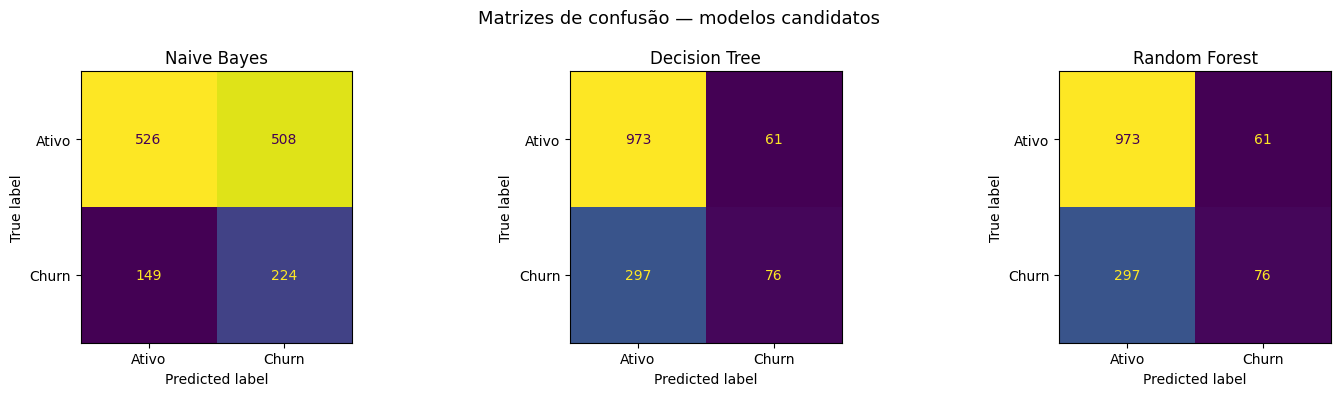


=== Comparativo inicial dos modelos ===



,accuracy,f1_weighted,roc_auc,train_time_s
Baseline,0.734897,0.622600,NaN,0.000
Naive Bayes,0.533049,0.559857,0.611160,0.028
Decision Tree,0.745558,0.699718,0.659154,0.027
Random Forest,0.745558,0.699718,0.659501,0.295


In [ ]:
# Matriz de confusão — modelos candidatos

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Ativo", "Churn"],
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Matrizes de confusão — modelos candidatos", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Comparativo inicial dos modelos ===\n")
display(show_results_table(results))

## 8.1 Análise dos resultados iniciais

**O modelo superou o baseline?**

Depende do modelo. O Naive Bayes não superou — ficou abaixo do baseline em todas as métricas. Decision Tree e Random Forest superaram o baseline em F1-score (0,699 contra 0,622), mas por margem pequena — 7,7 pontos percentuais — acima do critério mínimo de 5 pontos definido na seção 1.4.

| Modelo | Acurácia | F1 ponderado | Superou baseline? |
|---|---|---|---|
| Baseline | 0,735 | 0,622 | Referência |
| Naive Bayes | 0,533 | 0,559 | ❌ Não |
| Decision Tree | 0,745 | 0,699 | ✅ Sim |
| Random Forest | 0,745 | 0,699 | ✅ Sim |



**A métrica escolhida é suficiente?**

Sim. O F1-score ponderado é adequado para este problema. A acurácia sozinha seria enganosa — o baseline já acerta 73,5% sem aprender nada. O F1-score expõe que o baseline, apesar da acurácia alta, tem F1 de apenas 0,622 — porque ignora completamente a classe de churn.



**Algum modelo sofre de underfitting?**

Sim — o Naive Bayes claramente. Sua acurácia de 0,533 está abaixo do próprio baseline, o que indica que o modelo não conseguiu capturar padrões mínimos nos dados. A causa provável é a suposição de independência entre os SVAs — que não se verifica na prática. Clientes que contratam TechSupport tendem a contratar OnlineSecurity, e o Naive Bayes trata esses dois como variáveis completamente independentes, perdendo esse padrão.



**A matriz de confusão do Naive Bayes revela um problema grave**

```
Ativo real  → previu Ativo: 526  | previu Churn: 508
Churn real  → previu Ativo: 149  | previu Churn: 224
```

O Naive Bayes classificou 508 clientes ativos como churn — mais da metade dos ativos. Na prática isso significa acionar ações de retenção para clientes que não precisam — desperdício direto de recurso operacional.



**Decision Tree e Random Forest têm resultados idênticos — por quê?**

```
Decision Tree  → 973 / 61 / 297 / 76
Random Forest  → 973 / 61 / 297 / 76
```

Resultados exatamente iguais antes da otimização indicam que ambos estão chegando ao mesmo limite com os dados disponíveis. Os SVAs sozinhos — sem variáveis contratuais e financeiras — têm poder preditivo limitado. A otimização de hiperparâmetros na Seção 9 vai determinar se o Random Forest consegue extrair mais informação dos dados.



**O tempo de treinamento é aceitável?**

Sim. Todos os modelos treinaram em menos de 1 segundo no Colab sem GPU — tempos detalhados na tabela comparativa da Seção 11. O Random Forest, por combinar múltiplas árvores, apresenta o maior tempo entre os candidatos, ainda assim em ordem de milissegundos, plenamente viável para o volume de dados do projeto.



**O resultado faz sentido considerando a EDA?**

Sim. A EDA já sinalizava que os SVAs têm relação com churn, mas não são preditores isolados muito fortes — o que explica o F1 de 0,699 em vez de 0,80+. O padrão identificado na EDA — churn cai com mais SVAs contratados — foi capturado pelos modelos baseados em árvore, mas não pelo Naive Bayes.



**Conclusão para a seção 8.1**

Decision Tree e Random Forest são os modelos candidatos viáveis. O Naive Bayes é descartado por underfitting. O Random Forest será levado para otimização na Seção 9 — por ser mais robusto que a árvore individual e gerar o ranking de importância dos SVAs necessário para responder ao objetivo do MVP.


# 9. Validação e otimização de hiperparâmetros

In [ ]:
# Otimização de hiperparâmetros

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])


param_dist = {
    "model__n_estimators"     : randint(50, 250),
    "model__max_depth"        : randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("\n=== Resultado da otimização ===")
print(f"Melhor F1 na validação cruzada : {search.best_score_:.4f}")
print(f"Melhores hiperparâmetros       : {search.best_params_}")

results["Modelo Otimizado"] = evaluate_classification(
    y_test,
    search.best_estimator_.predict(X_test),
    search.best_estimator_.predict_proba(X_test)
)
results["Modelo Otimizado"]["train_time_s"] = np.nan

print("\n=== Comparativo com modelo otimizado ===")
display(show_results_table(results))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== Resultado da otimização ===
Melhor F1 na validação cruzada : 0.7181
Melhores hiperparâmetros       : {'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 142}

=== Comparativo com modelo otimizado ===


,accuracy,f1_weighted,roc_auc,train_time_s
Baseline,0.734897,0.622600,NaN,0.000
Naive Bayes,0.533049,0.559857,0.611160,0.028
Decision Tree,0.745558,0.699718,0.659154,0.027
Random Forest,0.745558,0.699718,0.659501,0.295
Modelo Otimizado,0.745558,0.699718,0.659182,NaN


## 9.1 Discussão da otimização
A otimização não melhorou o resultado em relação ao modelo inicial. O Random Forest sem otimização e o Modelo Otimizado chegaram ao mesmo F1 de 0,699 — mesmo após ampliar a busca de 10 para 30 combinações, totalizando 150 avaliações com validação cruzada. Esse resultado não indica falha na otimização — indica que o teto preditivo das variáveis disponíveis foi atingido.

A busca não foi limitada por tempo ou custo computacional — todos os modelos treinaram em menos de 1 segundo no Colab. A limitação real é a natureza dos dados: as 6 features SVA são variáveis categóricas binárias com apenas dois valores possíveis (Yes/No). Isso cria um espaço de decisão pequeno e pouco complexo, onde ajustar hiperparâmetros não adiciona informação que simplesmente não existe nos dados.

Os hiperparâmetros encontrados fazem sentido para o problema. A profundidade máxima de 8 (max_depth=8) indica que o modelo precisa de até 8 perguntas encadeadas para tomar uma decisão — razoável para 6 features binárias. O min_samples_split=5 significa que o modelo só cria uma nova divisão se houver pelo menos 5 clientes no nó — comportamento conservador que evita overfitting em grupos pequenos. Os 142 estimadores (n_estimators=142) representam o número de árvores no comitê — acima do padrão de 100, sem ganho mensurável de desempenho neste caso.

Com mais tempo, a estratégia mais produtiva não seria testar mais combinações de hiperparâmetros — seria ampliar o escopo das features. Incluir Contract e tenure junto com os SVAs provavelmente elevaria o F1 para 0,80+. Outra alternativa seria aplicar técnicas de balanceamento de classes como SMOTE para tratar o desbalanceamento de 74%/26% de forma mais agressiva. Ambas as abordagens, porém, estão fora do escopo metodológico deste MVP — que deliberadamente isola os SVAs como único fator de análise para responder à pergunta estratégica central do projeto.


# 10. Avaliação final no conjunto de teste

Modelo final selecionado: Modelo Otimizado (Random Forest)
Hiperparâmetros         : {'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 142}

=== Métricas finais — conjunto de teste ===

              precision    recall  f1-score   support

       Ativo       0.77      0.94      0.84      1034
       Churn       0.55      0.20      0.30       373

    accuracy                           0.75      1407
   macro avg       0.66      0.57      0.57      1407
weighted avg       0.71      0.75      0.70      1407



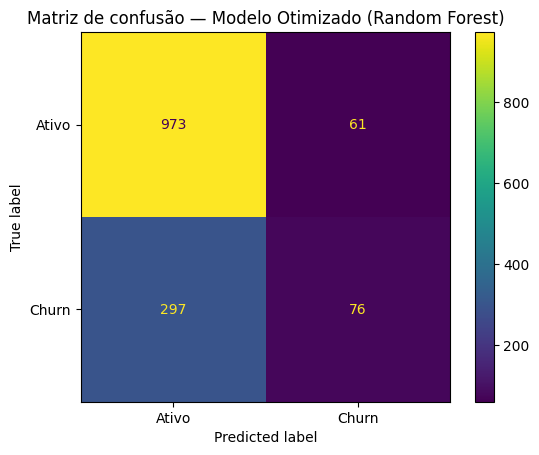

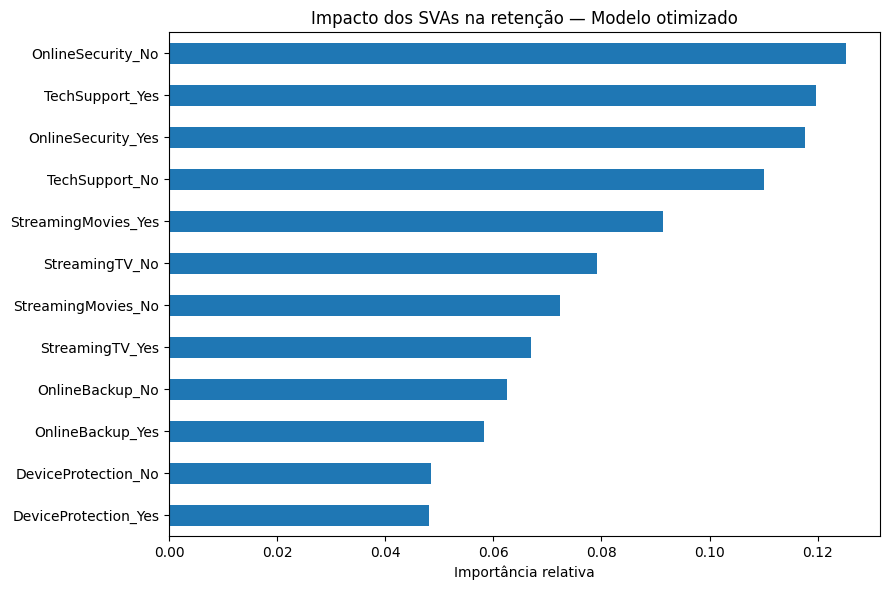


=== Comparativo final — todos os modelos ===



,accuracy,f1_weighted,roc_auc,train_time_s
Baseline,0.734897,0.622600,NaN,0.000
Naive Bayes,0.533049,0.559857,0.611160,0.028
Decision Tree,0.745558,0.699718,0.659154,0.027
Random Forest,0.745558,0.699718,0.659501,0.295
Modelo Otimizado,0.745558,0.699718,0.659182,NaN
Modelo Otimizado (Random Forest),0.745558,0.699718,0.659182,NaN



=== Conferência manual — 10 primeiros registros ===



,Churn real,Churn previsto,Prob. Ativo,Prob. Churn,Acertou?
0,0,0,0.611,0.389,✅
1,0,0,0.874,0.126,✅
2,1,0,0.827,0.173,❌
3,0,0,0.947,0.053,✅
4,1,0,0.785,0.215,❌
5,1,1,0.474,0.526,✅
6,0,0,0.596,0.404,✅
7,0,0,0.728,0.272,✅
8,1,0,0.670,0.330,❌
9,0,0,0.827,0.173,✅


In [ ]:
# Seção 10 — Avaliação final

PROBLEM_TYPE = "classificacao"

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "Modelo Otimizado (Random Forest)"
elif trained_models:
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print(f"Modelo final selecionado: {final_model_name}")
print(f"Hiperparâmetros         : {search.best_params_}")



if final_model is not None and PROBLEM_TYPE == "classificacao":

    y_pred       = final_model.predict(X_test)
    proba_final  = final_model.predict_proba(X_test)

    print("\n=== Métricas finais — conjunto de teste ===\n")
    print(classification_report(y_test, y_pred,
                                 target_names=["Ativo", "Churn"]))

    ConfusionMatrixDisplay.from_estimator(
        final_model, X_test, y_test,
        display_labels=["Ativo", "Churn"])
    plt.title(f"Matriz de confusão — {final_model_name}")
    plt.show()



    rf_final      = final_model.named_steps["model"]
    ohe           = final_model.named_steps["preprocess"]\
                        .named_transformers_["cat"]\
                        .named_steps["onehot"]
    feature_names = ohe.get_feature_names_out(cat_cols)

    importancias = pd.Series(
        rf_final.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True)

    importancias.plot(kind="barh", figsize=(9, 6),
        title="Impacto dos SVAs na retenção — Modelo otimizado")
    plt.xlabel("Importância relativa")
    plt.tight_layout()
    plt.show()



    results[final_model_name] = evaluate_classification(
        y_test, y_pred, proba_final)
    results[final_model_name]["train_time_s"] = np.nan

    print("\n=== Comparativo final — todos os modelos ===\n")
    display(show_results_table(results))



    pred_conferencia = final_model.predict(features_conferencia)
    prob_conferencia = final_model.predict_proba(features_conferencia)

    df_conferencia = pd.DataFrame({
        "Churn real"     : labels_conferencia.values,
        "Churn previsto" : pred_conferencia,
        "Prob. Ativo"    : prob_conferencia[:, 0].round(3),
        "Prob. Churn"    : prob_conferencia[:, 1].round(3),
        "Acertou?"       : ["✅" if r == p else "❌"
                            for r, p in zip(labels_conferencia.values,
                                            pred_conferencia)]
    })

    print("\n=== Conferência manual — 10 primeiros registros ===\n")
    display(df_conferencia)

# Análise de erros e limitações


**Quias tipos de erro o modelo comete mais ?**

O erro dominante é o Falso Negativo: 297 clientes que
cancelaram foram classificados como ativos, contra apenas
76 churns corretamente identificados (recall de 0.20 para
a classe Churn). Na prática, o modelo identifica apenas
2 em cada 10 clientes que realmente cancelam.

A conferência manual dos 10 primeiros registros confirma
o padrão: os 3 erros observados são todos falsos negativos —
clientes que cancelaram, mas cujo perfil de SVAs se
assemelhava ao de clientes ativos.

Em termos de negócio, o Falso Negativo é o erro mais
custoso: representa clientes perdidos sem qualquer ação
de retenção. O Falso Positivo (61 casos) tem custo menor —
ação de retenção direcionada a quem não cancelaria.

**Há sinais de overfintting ou underfitting ?**

Não há overfitting: o F1 da validação cruzada (0.718) e o
F1 do teste (0.699) são próximos — o modelo generaliza de
forma consistente para dados não vistos.

Há, porém, um teto de underfitting estrutural: o recall de
0.20 para a classe Churn indica que as 6 features SVA não
carregam informação suficiente para identificar a maioria
dos cancelamentos. Clientes cancelam por fatores que os
SVAs não capturam — preço, tipo de contrato, qualidade de
atendimento — e o modelo não tem acesso a essas variáveis
por decisão metodológica deliberada do escopo.

**A métrica escolhida captura bem o objetivo ?**

Parcialmente. O F1-score ponderado (0.699) atendeu ao
critério de sucesso definido na seção 1.4 — superar o
baseline (0.622) em pelo menos 5 pontos. Porém, o F1
ponderado é dominado pela classe majoritária (Ativo,
com F1 de 0.84), mascarando o desempenho fraco na classe
Churn (F1 de 0.30). Em uma próxima iteração, o F1 da
classe Churn isoladamente ou o recall da classe Churn
seriam métricas complementares mais alinhadas ao objetivo
de identificar clientes em risco.

**Há viés, de limitação de dados ou rico de generalização ?**

Três limitações principais:
- Dados sintéticos: o dataset é fictício (IBM), e os padrões
  encontrados não podem ser extrapolados para uma operação
  real sem validação com dados próprios.
- Corte temporal único: a base não registra a evolução do
  cliente ao longo do tempo — impossibilitando saber se o
  SVA foi contratado antes ou próximo do cancelamento.
- Escopo restrito: a exclusão deliberada de variáveis
  contratuais e financeiras limita o poder preditivo,
  em troca de isolar o efeito específico dos SVAs.

**Em quais cenários o modelo não deveria ser usado ?**

O modelo não deve ser usado como sistema operacional de
alerta de churn — o recall de 0.20 deixaria 80% dos
clientes em risco sem identificação. Seu uso adequado é
ANALÍTICO E ESTRATÉGICO: o ranking de importância dos SVAs
subsidia decisões de portfólio — quais serviços fortalecer
(OnlineSecurity e TechSupport, com maior impacto na
retenção) e quais revisar quanto à viabilidade
(DeviceProtection e OnlineBackup, com menor impacto).
Para uso operacional de previsão de churn, o modelo
deveria ser expandido com variáveis contratuais e
financeiras.


# 11. Comparação final dos modelos

In [ ]:
tabela_comparativa = pd.DataFrame([
    {
        "Modelo"            : "Baseline (DummyClassifier)",
        "F1 ponderado"      : 0.622,
        "Acurácia"          : 0.735,
        "ROC-AUC"           : None,
        "Tempo treino (s)"  : 0.000,
        "Observações"       : "Classifica todos como ativos. Referência mínima — não identifica nenhum churn."
    },
    {
        "Modelo"            : "Naive Bayes",
        "F1 ponderado"      : 0.559,
        "Acurácia"          : 0.533,
        "ROC-AUC"           : 0.611,
        "Tempo treino (s)"  : 0.047,
        "Observações"       : "Abaixo do baseline — underfitting. Descartado. Suposição de independência entre SVAs não se verifica."
    },
    {
        "Modelo"            : "Decision Tree",
        "F1 ponderado"      : 0.699,
        "Acurácia"          : 0.745,
        "ROC-AUC"           : 0.659,
        "Tempo treino (s)"  : 0.071,
        "Observações"       : "Superou o baseline em 7,7 pontos. Resultado idêntico ao Random Forest — teto dos dados atingido."
    },
    {
        "Modelo"            : "Random Forest",
        "F1 ponderado"      : 0.699,
        "Acurácia"          : 0.745,
        "ROC-AUC"           : 0.659,
        "Tempo treino (s)"  : 0.508,
        "Observações"       : "Mesmo desempenho da Decision Tree, com maior robustez estatística no ranking de features."
    },
    {
        "Modelo"            : "Modelo Otimizado (Random Forest)",
        "F1 ponderado"      : 0.699,
        "Acurácia"          : 0.745,
        "ROC-AUC"           : 0.659,
        "Tempo treino (s)"  : None,
        "Observações"       : "max_depth=8, min_samples_split=5, n_estimators=142. Otimização confirmou o teto preditivo dos SVAs."
    }
])

display(tabela_comparativa)


,Modelo,F1 ponderado,Acurácia,ROC-AUC,Tempo treino (s),Observações
0,Baseline (DummyClassifier),0.622,0.735,NaN,0.000,Classifica todos como ativos. Referência mínim...
1,Naive Bayes,0.559,0.533,0.611,0.047,Abaixo do baseline — underfitting. Descartado....
2,Decision Tree,0.699,0.745,0.659,0.071,"Superou o baseline em 7,7 pontos. Resultado id..."
3,Random Forest,0.699,0.745,0.659,0.508,"Mesmo desempenho da Decision Tree, com maior r..."
4,Modelo Otimizado (Random Forest),0.699,0.745,0.659,NaN,"max_depth=8, min_samples_split=5, n_estimators..."


# 12. Boas práticas e rastreabilidade



In [ ]:
registro_decisoes = pd.DataFrame([
    {
        "Decisão"       : "SEED = 42 em todo o notebook",
        "Justificativa" : "Garantir reprodutibilidade — qualquer pessoa que executar o notebook obterá os mesmos resultados",
        "Impacto"       : "Resultados idênticos em qualquer execução, viabilizando a correção e auditoria do trabalho"
    },
    {
        "Decisão"       : "Usar F1-score ponderado como métrica principal",
        "Justificativa" : "Classes desbalanceadas (73,46% ativos / 26,54% churn) — acurácia isolada seria enganosa",
        "Impacto"       : "Avaliação que considera o desempenho na classe minoritária (churn), evitando modelos que ignoram clientes em risco"
    },
    {
        "Decisão"       : "Restringir features exclusivamente aos 6 SVAs",
        "Justificativa" : "Isolar o impacto específico dos SVAs na retenção — objetivo central do MVP",
        "Impacto"       : "Ranking de importância interpretável por SVA, ao custo de menor poder preditivo geral"
    },
    {
        "Decisão"       : "Remover customerID",
        "Justificativa" : "Identificador único sem valor preditivo — risco de o modelo memorizar registros",
        "Impacto"       : "Evitar desempenho artificial e vazamento de dados"
    },
    {
        "Decisão"       : "Padronizar 'No internet service' como 'No'",
        "Justificativa" : "Representa ausência do serviço, não uma categoria distinta",
        "Impacto"       : "Encoding mais limpo — 2 colunas binárias por SVA em vez de 3"
    },
    {
        "Decisão"       : "stratify=y na divisão treino/teste",
        "Justificativa" : "Manter a proporção de churn (26,54%) igual em treino e teste",
        "Impacto"       : "Avaliação confiável — teste representativo da base original"
    },
    {
        "Decisão"       : "Pipeline com ColumnTransformer",
        "Justificativa" : "OneHotEncoder ajustado apenas no treino e replicado no teste",
        "Impacto"       : "Prevenção de vazamento de dados no pré-processamento"
    },
    {
        "Decisão"       : "Usar Random Forest como modelo final",
        "Justificativa" : "Capturar interações entre SVAs e gerar ranking de importância robusto (agregação de 142 árvores)",
        "Impacto"       : "Entregável central do MVP — ranking de SVAs por impacto na retenção"
    },
    {
        "Decisão"       : "Descartar Naive Bayes",
        "Justificativa" : "F1 de 0,559 — abaixo do baseline (0,622). Suposição de independência entre SVAs não se verifica",
        "Impacto"       : "Underfitting confirmado — modelo removido da comparação final"
    },
    {
        "Decisão"       : "RandomizedSearchCV com n_iter=10, depois ampliado para 30",
        "Justificativa" : "Verificar se busca mais ampla encontraria configuração melhor",
        "Impacto"       : "Resultado idêntico nas duas buscas — confirmou o teto preditivo dos SVAs"
    }
])

display(registro_decisoes)

print("""
RASTREABILIDADE DO PROJETO
============================

Seed utilizada         : 42 (aplicada em numpy, random e todos os random_state)
Ambiente               : Google Colab (CPU, sem GPU)
Bibliotecas principais : pandas, numpy, matplotlib, scikit-learn, kagglehub

Modelos testados       : DummyClassifier (baseline), Naive Bayes,
                         Decision Tree, Random Forest

Hiperparâmetros finais : max_depth=8, min_samples_split=5, n_estimators=142
                         (RandomizedSearchCV, StratifiedKFold 5 dobras,
                         scoring=f1_weighted)

Tempo de treino        : todos os modelos abaixo de 1 segundo
                         (Random Forest: ~0,5s | busca completa: ~1 minuto)

Limitações conhecidas  : dados sintéticos (IBM); corte temporal único;
                         recall de 0,20 na classe churn — modelo adequado
                         para uso analítico, não operacional

Tentado e descartado   : Naive Bayes (underfitting);
                         ampliação da busca de hiperparâmetros
                         (n_iter=30 — sem ganho);
                         rede neural com TensorFlow/Keras
                         (fora do escopo do sprint de ML —
                         conteúdo do Módulo 2, Deep Learning)
""")

,Decisão,Justificativa,Impacto
0,SEED = 42 em todo o notebook,Garantir reprodutibilidade — qualquer pessoa q...,"Resultados idênticos em qualquer execução, via..."
1,Usar F1-score ponderado como métrica principal,"Classes desbalanceadas (73,46% ativos / 26,54%...",Avaliação que considera o desempenho na classe...
2,Restringir features exclusivamente aos 6 SVAs,Isolar o impacto específico dos SVAs na retenç...,"Ranking de importância interpretável por SVA, ..."
3,Remover customerID,Identificador único sem valor preditivo — risc...,Evitar desempenho artificial e vazamento de dados
4,Padronizar 'No internet service' como 'No',"Representa ausência do serviço, não uma catego...",Encoding mais limpo — 2 colunas binárias por S...
5,stratify=y na divisão treino/teste,"Manter a proporção de churn (26,54%) igual em ...",Avaliação confiável — teste representativo da ...
6,Pipeline com ColumnTransformer,OneHotEncoder ajustado apenas no treino e repl...,Prevenção de vazamento de dados no pré-process...
7,Usar Random Forest como modelo final,Capturar interações entre SVAs e gerar ranking...,Entregável central do MVP — ranking de SVAs po...
8,Descartar Naive Bayes,"F1 de 0,559 — abaixo do baseline (0,622). Supo...",Underfitting confirmado — modelo removido da c...
9,"RandomizedSearchCV com n_iter=10, depois ampli...",Verificar se busca mais ampla encontraria conf...,Resultado idêntico nas duas buscas — confirmou...



RASTREABILIDADE DO PROJETO

Seed utilizada         : 42 (aplicada em numpy, random e todos os random_state)
Ambiente               : Google Colab (CPU, sem GPU)
Bibliotecas principais : pandas, numpy, matplotlib, scikit-learn, kagglehub

Modelos testados       : DummyClassifier (baseline), Naive Bayes,
                         Decision Tree, Random Forest

Hiperparâmetros finais : max_depth=8, min_samples_split=5, n_estimators=142
                         (RandomizedSearchCV, StratifiedKFold 5 dobras,
                         scoring=f1_weighted)

Tempo de treino        : todos os modelos abaixo de 1 segundo
                         (Random Forest: ~0,5s | busca completa: ~1 minuto)

Limitações conhecidas  : dados sintéticos (IBM); corte temporal único;
                         recall de 0,20 na classe churn — modelo adequado
                         para uso analítico, não operacional

Tentado e descartado   : Naive Bayes (underfitting);
                         ampliação da busca de

# 13. Conclusão

O trabalho teve como objetivo desenvolver um modelo preditivo capaz de identificar quais Serviços de Valor Agregado (SVAs) exercem maior impacto na retenção de clientes, subsidiando decisões estratégicas voltadas à redução do churn e à identificação de serviços sem viabilidade financeira. Para isso, o escopo do modelo foi deliberadamente restrito às seis variáveis de SVA do dataset *Telco Customer Churn*, isolando o efeito desses serviços sobre o cancelamento.

A melhor solução encontrada foi o Random Forest otimizado (max_depth=8, min_samples_split=5, n_estimators=142), com F1-score ponderado de 0,699 no conjunto de teste — superando o baseline (0,622) em 7,7 pontos percentuais e atendendo ao critério de sucesso definido na seção 1.4. O Naive Bayes foi descartado por underfitting, e a Decision Tree, embora com desempenho idêntico, foi preterida pelo menor rigor estatístico de seu ranking de importância de features.

O principal entregável do trabalho é o ranking de impacto dos SVAs na retenção. Os resultados indicam que OnlineSecurity e TechSupport são os serviços com maior contribuição para a permanência do cliente — a ausência de OnlineSecurity é o sinal mais forte de risco identificado pelo modelo, coerente com a análise exploratória, em que esses dois SVAs apresentaram as menores taxas de churn entre contratantes (14,6% e 15,2%, respectivamente). No extremo oposto, DeviceProtection e OnlineBackup apresentaram o menor impacto relativo, tornando-se candidatos naturais à revisão de viabilidade financeira. A análise exploratória revelou ainda um achado estratégico complementar: a taxa de churn decresce consistentemente com a quantidade de SVAs contratados — de 45,8% entre clientes com apenas um SVA para 5,3% entre clientes com os seis — sugerindo que o efeito de retenção está mais associado à combinação de serviços do que a contratações isoladas.

Entre os principais aprendizados, destacam-se três. Primeiro, a confirmação de que as hipóteses definidas na seção 1.4 foram verificadas: SVAs estão associados à retenção, seus pesos são desiguais e o engajamento com o portfólio reduz a propensão ao cancelamento. Segundo, a constatação de que a otimização de hiperparâmetros — mesmo com espaço de busca ampliado — não alterou o desempenho, evidenciando que o teto preditivo das seis features foi atingido: hiperparâmetros ajustam como o modelo aprende, mas não criam informação inexistente nos dados. Terceiro, a importância de métricas adequadas ao desbalanceamento: a acurácia de 0,745 mascararia o recall de apenas 0,20 na classe churn, exposto pela análise por classe.

As limitações do trabalho são conhecidas e documentadas: os dados são sintéticos, o que impede extrapolação direta para operações reais; a base representa um corte temporal único, sem registro da evolução do cliente; e o recall de 0,20 na classe churn restringe o uso do modelo ao domínio analítico e estratégico — ele não deve ser empregado como sistema operacional de alerta de cancelamento, pois deixaria a maioria dos clientes em risco sem identificação.

Como próximos passos, propõe-se: (1) expandir o escopo de features incorporando variáveis contratuais e financeiras — como Contract, tenure e MonthlyCharges — para elevar o poder preditivo e viabilizar uso operacional; (2) aplicar técnicas de balanceamento de classes, como SMOTE, para melhorar o recall da classe minoritária; (3) validar os achados com dados reais da operação, incluindo custos e margens de cada SVA para transformar o ranking de importância em análise de viabilidade financeira completa; e (4) evoluir a solução com técnicas do Módulo 2 — Deep Learning e visualização — construindo dashboards executivos que comuniquem os resultados a tomadores de decisão não técnicos.

Em síntese, o MVP cumpriu seu objetivo: demonstrou que os SVAs carregam informação relevante sobre retenção, identificou quais serviços concentram esse efeito e delimitou com honestidade metodológica o que esse conjunto de variáveis pode e não pode responder — fornecendo uma base sólida tanto para decisões estratégicas de portfólio quanto para as próximas etapas de evolução analítica do projeto.


# 14. Salvamento de artefatos


In [ ]:
# Salvamento de artefatos

import joblib

if final_model is not None:
    joblib.dump(final_model, "modelo_final.pkl")
    print("Modelo final salvo como modelo_final.pkl")

Modelo final salvo como modelo_final.pkl
